In [12]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


import pandas as pd
train = pd.read_pickle('../data/original_raw/train_split.pkl')
test = pd.read_pickle('../data/original_raw/test_data.pkl')
validation = pd.read_pickle('../data/original_raw/val_data.pkl')
unique_counts = train['failureType'].value_counts()

# 2. Check which strings have exactly 1 associated number
# has_only_one = unique_counts == 1

print("--- Unique counts per string ---")
print(unique_counts)

# print("\n--- Strings with exactly one associated number ---")
# print(has_only_one)

--- Unique counts per string ---
failureType
none         22037
Edge-Ring     5808
Edge-Loc      3113
Center        2576
Loc           2156
Scratch        716
Random         520
Donut          333
Near-full       89
Name: count, dtype: int64


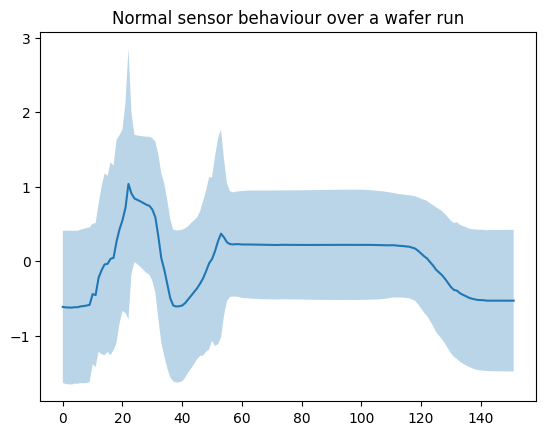

In [1]:
import numpy as np
from sktime.datasets import load_from_tsfile
X, y = load_from_tsfile("../data/original_raw/Wafer_TRAIN.ts")
X_filtered = X.iloc[np.argwhere(y=='1').flatten()]
data_2d = np.array(X_filtered['dim_0'].tolist())

# per-timestep mean and std across all normal samples
timestep_mean = data_2d.mean(axis=0)  # shape: (n_timesteps,)
timestep_std = data_2d.std(axis=0)    # shape: (n_timesteps,)

import matplotlib.pyplot as plt
plt.plot(timestep_mean, label='mean')
plt.fill_between(range(len(timestep_mean)),
                 timestep_mean - timestep_std,
                 timestep_mean + timestep_std,
                 alpha=0.3, label='±1 std')
plt.title('Normal sensor behaviour over a wafer run')
plt.show()

In [7]:
steady_state = data_2d[:, 55:120]
ss_mean = steady_state.mean(axis=0)
ss_std = steady_state.std(axis=0)

noise_ratio = ss_std.mean() / (ss_mean.mean() + 1e-9)
print(f"Noise ratio in steady state: {noise_ratio:.4f}")


Noise ratio in steady state: 3.3743


In [18]:
gas_flow_normal    = np.random.normal(100, 2)    # ±2 sccm
temperature_normal = np.random.normal(350, 3)    # ±3°C  
pressure_normal    = np.random.normal(1.2, 0.02) # ±0.02 torr
x = 0

In [20]:
BASELINE = { "temp": [temperature_normal,x], "gas_flow": [gas_flow_normal,x+1], "pressure": [pressure_normal,x+2] }
for key,[start,end] in BASELINE.items():
    print (start, end)

351.9430656143021 0
99.72347139765763 1
1.2304605971281604 2


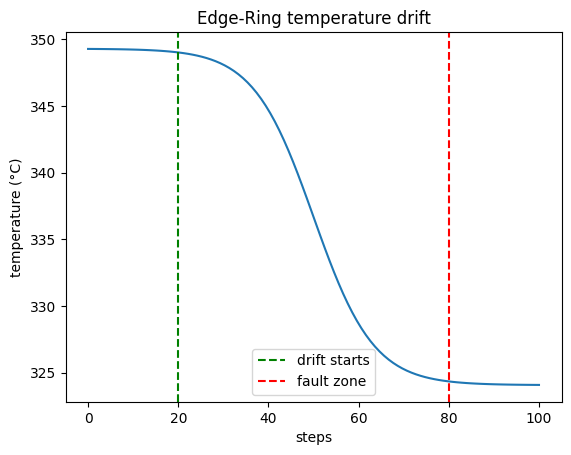

In [21]:
import matplotlib.pyplot as plt

t = np.linspace(0, 100, 100)
t_mid = 50
steepness = 0.15

# Test with temperature, Edge-Ring fault
start = np.random.normal(350, 3)
end = np.random.normal(325, 4)

drift = sigmoid_drift(t, start, end, t_mid, steepness)

plt.plot(t, drift)
plt.axvline(x=20, color='g', linestyle='--', label='drift starts')
plt.axvline(x=80, color='r', linestyle='--', label='fault zone')
plt.xlabel('steps')
plt.ylabel('temperature (°C)')
plt.title('Edge-Ring temperature drift')
plt.legend()
plt.show()

In [ ]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


import pandas as pd
train = pd.read_pickle('../data/original_raw/train_split.pkl')
# test = pd.read_pickle('../data/original_raw/test_data.pkl')
# validation = pd.read_pickle('../data/original_raw/val_data.pkl')
# print ("Train Data Distribution\n", train.failureType.value_counts())
# print ("Test Data Distribution\n", test.failureType.value_counts())
# print ("Validation Data Distribution\n", validation.failureType.value_counts())


# Create a random 2D array (grayscale) or 3D array (RGB)
# fig, axes = plt.subplots(3, 4, figsize=(10, 10))
# for i in range(12):
#     print (f"Displaying wafer map for defect type: {"Scratch"}, index: {i}")
#     img = train[train.failureType == "Scratch"].iloc[i].waferMap  # Assuming waferMap is a 2D array
#     print(f"Image shape: {img.shape}, dtype: {img.dtype}")
#     axes[i//4, i%4].imshow(img,cmap='gray') # Use 'gray' for 2D arrays
#     axes[i//4, i%4].axis('off')               # Hide axis ticks
# plt.show()


# for defect_type in train.failureType.unique():
#     defect_samples = train[train.failureType == defect_type]
#     defect_samples["map_shape"] = defect_samples.waferMap.apply(lambda x: x.shape)

#     # Now dot notation works perfectly and safely!
#     print (f"Defect type: {defect_type} Total samples: {len(defect_samples)}")
#     print ("Top 5 wafer maps total samples:", defect_samples.map_shape.value_counts().head(10).sum( ))
#     print (f"Map shape distribution:")
#     print (defect_samples.map_shape.value_counts().head(5))

defect_type = "Scratch"
defect_samples = train[train.failureType == defect_type]
defect_samples["map_shape"] = defect_samples.waferMap.apply(lambda x: x.shape)

# Now dot notation works perfectly and safely!
print (f"Defect type: {defect_type} Total samples: {len(defect_samples)}")
print ("Top 5 wafer maps total samples:", defect_samples.map_shape.value_counts().head(10).sum( ))
print (f"Map shape distribution:")
print (defect_samples.map_shape.value_counts().head(10))



Defect type: Scratch Total samples: 716
Top 5 wafer maps total samples: 336
Map shape distribution:
map_shape
(29, 26)    45
(30, 34)    43
(26, 26)    42
(39, 37)    40
(52, 59)    33
(44, 41)    33
(33, 29)    29
(41, 33)    28
(42, 44)    22
(50, 43)    21
Name: count, dtype: int64


C:\Users\sarah\AppData\Local\Temp\ipykernel_2412\552802531.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  defect_samples["map_shape"] = defect_samples.waferMap.apply(lambda x: x.shape)


In [ ]:
target_size = 36
# 1. Extract height and width from the map_shape tuple
defect_samples['height'] = defect_samples['map_shape'].apply(lambda x: x[0])
defect_samples['width'] = defect_samples['map_shape'].apply(lambda x: x[1])

# 2. Create a boolean mask for images that are too small 
# (True if EITHER height or width is less than 36)
is_small = (defect_samples['height'] < 3) | (defect_samples['width'] < target_size)

# View how many you will keep vs discard
print("Image Size Distribution:")
print(is_small.value_counts().rename({True: f"Discard (< {target_size})", False: f"Keep (>= {target_size})"}))

# Optional: See exactly which small shapes are the most common before deleting
print("\nMost common small shapes:")
print(defect_samples[is_small]['map_shape'].value_counts().head(10))

# 3. Filter the dataframe to keep only the properly sized images
defect_samples_filtered = defect_samples[~is_small].drop(columns=['height', 'width'])

print(f"\nOriginal dataset size: {len(defect_samples)}")
print(f"Filtered dataset size: {len(defect_samples_filtered)}")

Image Size Distribution:
Discard (< 40)    387
Keep (>= 40)      329
Name: count, dtype: int64

Most common small shapes:
map_shape
(29, 26)    45
(30, 34)    43
(26, 26)    42
(39, 37)    40
(33, 29)    29
(41, 33)    28
(25, 27)    18
(49, 39)    16
(38, 38)    14
(35, 31)    14
Name: count, dtype: int64

Original dataset size: 716
Filtered dataset size: 329


C:\Users\sarah\AppData\Local\Temp\ipykernel_2412\3333729763.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  defect_samples['height'] = defect_samples['map_shape'].apply(lambda x: x[0])
C:\Users\sarah\AppData\Local\Temp\ipykernel_2412\3333729763.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  defect_samples['width'] = defect_samples['map_shape'].apply(lambda x: x[1])


C:\Users\sarah\AppData\Local\Temp\ipykernel_2412\1576280632.py:46: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  defect_samples["map_shape"] = defect_samples.waferMap.apply(lambda x: x.shape)


Original shape: (26, 26)
Original shape: (26, 26)


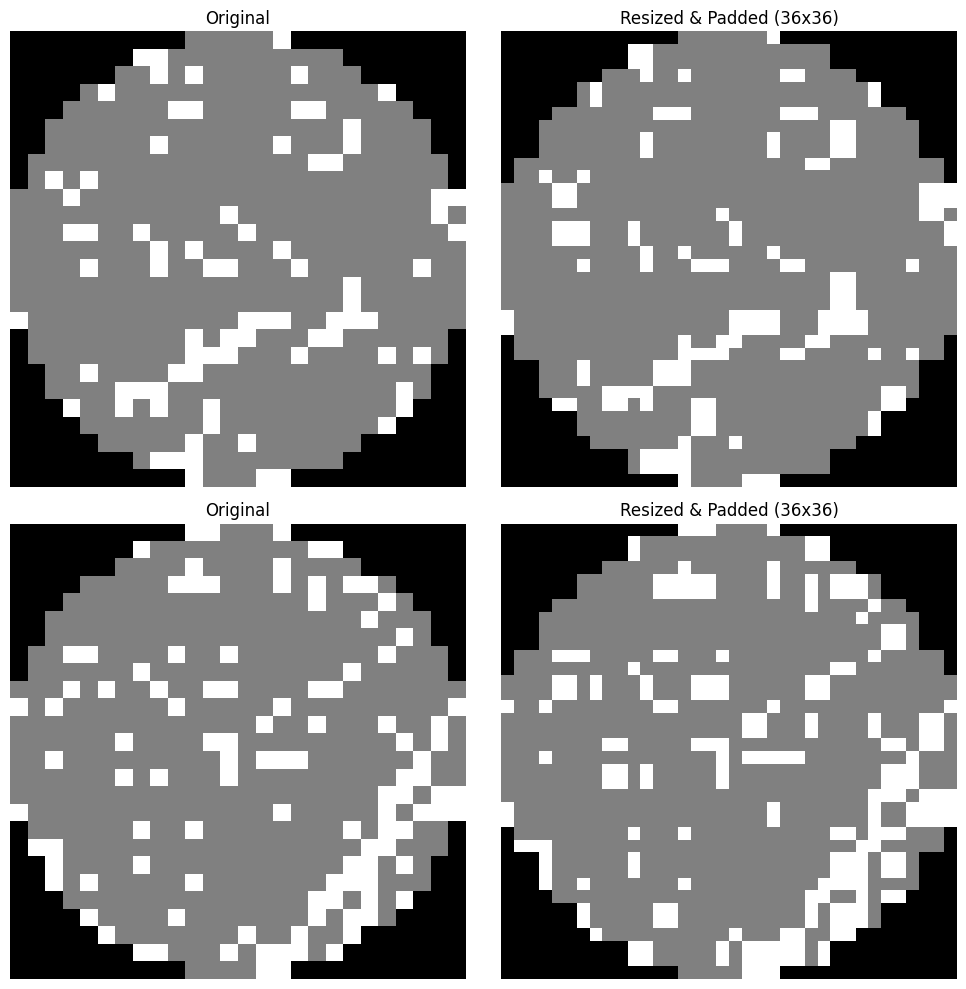

Original shape: (52, 59)
Original shape: (52, 59)


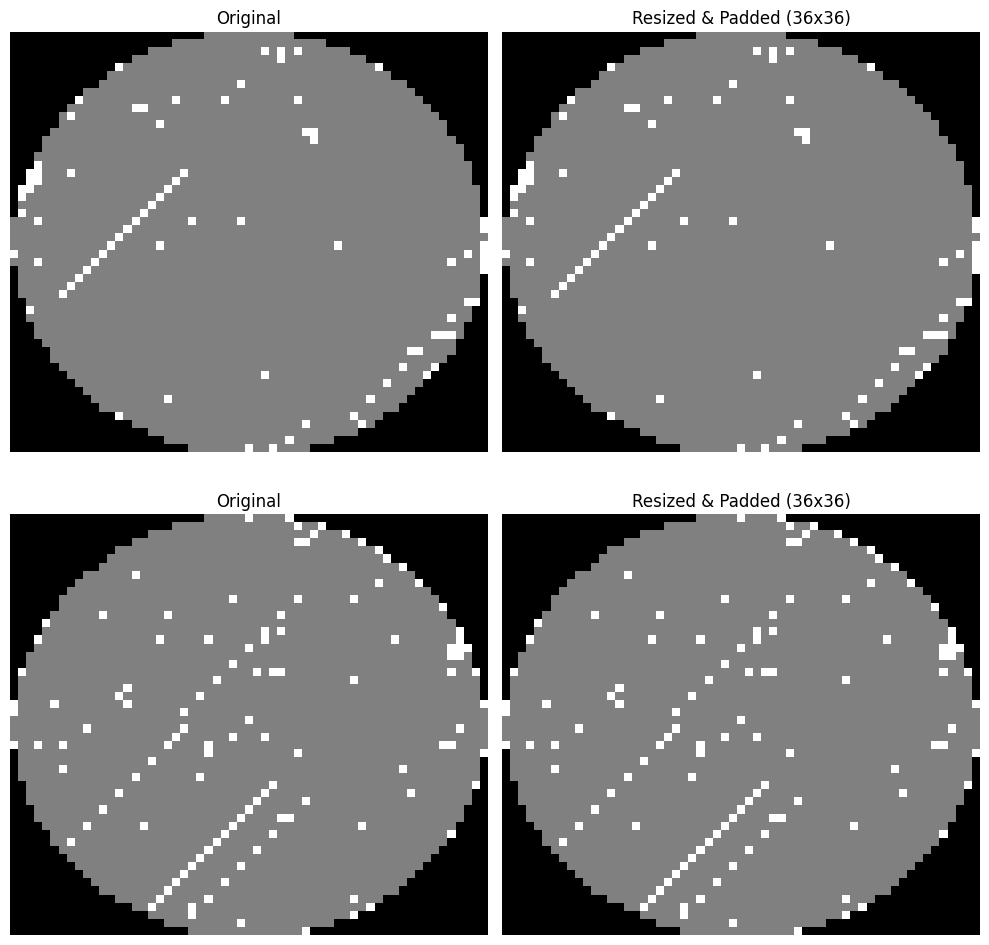

In [81]:
import torchvision.transforms.functional as F
target_size = 36

import numpy as np

from skimage.measure import block_reduce

def downsize_binary_preserve_foreground(img_array, block_h, block_w):
    """
    img_array: 2D numpy array, defect pixels = max value.
    block_h, block_w: how many source pixels map to each output pixel
                       (roughly source_size / target_size).
    Uses max-pooling so any defect pixel in a block survives.
    """
    return block_reduce(img_array, block_size=(block_h, block_w), func=np.max)

def resize_and_pad_image( img):  

    fill = 0  # Black padding

    width, height = img.size
    max_dim = max(width, height)
    if max_dim > target_size:
        return downsize_binary_preserve_foreground(np.array(img), block_h=max_dim//target_size, block_w=max_dim//target_size)

    # Always scale so the larger dimension fits target_size, preserving aspect ratio
    scale = target_size / max_dim
    new_w, new_h = round(width * scale), round(height * scale)
    img = F.resize(img, (new_h, new_w), interpolation=F.InterpolationMode.NEAREST)  # note: torchvision expects (h, w)

    width, height = new_w, new_h

    # Pad the shorter dimension to reach target_size
    pad_w = target_size - width
    pad_h = target_size - height
    
    # Split the padding equally on both sides
    pad_left = pad_w // 2
    pad_right = pad_w - pad_left
    pad_top = pad_h // 2
    pad_bottom = pad_h - pad_top
    img = F.pad(img, (pad_left, pad_top, pad_right, pad_bottom), fill=fill)
    return img

defect_samples = train[train.failureType == "Scratch"]
defect_samples["map_shape"] = defect_samples.waferMap.apply(lambda x: x.shape)

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
for i in range(2):
    img = defect_samples[defect_samples.map_shape == (26, 26)].iloc[i].waferMap
    print(f"Original shape: {img.shape}")
    
    img_pil = F.to_pil_image(img)
    img_resized_padded = resize_and_pad_image(img_pil)
    
    # Left column: Original Wafer Map
    axes[i, 0].imshow(img, cmap='gray')
    axes[i, 0].axis('off')
    axes[i, 0].set_title("Original")
    
    # Right column: Resized & Padded Wafer Map
    axes[i, 1].imshow(img_resized_padded, cmap='gray')
    axes[i, 1].axis('off')
    axes[i, 1].set_title(f"Resized & Padded ({target_size}x{target_size})")

plt.tight_layout()
plt.show()


fig, axes = plt.subplots(2, 2, figsize=(10, 10))

for i in range(2):
    img = defect_samples[defect_samples.map_shape == (52, 59)].iloc[i].waferMap
    print(f"Original shape: {img.shape}")
    
    img_pil = F.to_pil_image(img)
    img_resized_padded = resize_and_pad_image(img_pil)
    
    # Left column: Original Wafer Map
    axes[i, 0].imshow(img, cmap='gray')
    axes[i, 0].axis('off')
    axes[i, 0].set_title("Original")
    
    # Right column: Resized & Padded Wafer Map
    axes[i, 1].imshow(img_resized_padded, cmap='gray')
    axes[i, 1].axis('off')
    axes[i, 1].set_title(f"Resized & Padded ({target_size}x{target_size})")

plt.tight_layout()
plt.show()
    

In [10]:
# script/scratch_angle_histogram

import math
import math
from turtle import width

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torchvision.transforms.functional as F
from skimage.measure import block_reduce




def downsize_binary_preserve_foreground(img_array, block_h, block_w):
    """
    img_array: 2D numpy array, defect pixels = max value.
    block_h, block_w: how many source pixels map to each output pixel
                       (roughly source_size / target_size).
    Uses max-pooling so any defect pixel in a block survives.
    """
    return block_reduce(img_array, block_size=(block_h, block_w), func=np.max)

def resize_and_pad_image( img):  
    target_size = 32
    fill = 0  # Black padding

    width, height = img.size
    max_dim = max(width, height)
    if max_dim > target_size:
        block_h = max(1, math.ceil(height / target_size))
        block_w = max(1, math.ceil(width / target_size))
        img_arr = downsize_binary_preserve_foreground(np.array(img), block_h=block_h, block_w=block_w)
        img = F.to_pil_image(img_arr)
        width, height = img.size
        # fall through to padding below, don't return early
    else:
        scale = target_size / max_dim
        new_w, new_h = round(width * scale), round(height * scale)
        img = F.resize(img, (new_h, new_w), interpolation=F.InterpolationMode.NEAREST)
        width, height = new_w, new_h
    # Pad the shorter dimension to reach target_size
    pad_w = target_size - width
    pad_h = target_size - height
    
    # Split the padding equally on both sides
    pad_left = pad_w // 2
    pad_right = pad_w - pad_left
    pad_top = pad_h // 2
    pad_bottom = pad_h - pad_top
    img = F.pad(img, (pad_left, pad_top, pad_right, pad_bottom), fill=fill)
    return img


def get_defect_angle_and_linearity(img: np.ndarray, defect_value=None):
    """
    img: 2D numpy array (single-channel wafer map).
    defect_value: pixel value that represents a defect ("white").
        If None, assumes defect pixels are the maximum value in the image.

    Returns:
        angle_deg: dominant orientation angle in degrees, range [0, 180).
                   Returns None if fewer than 2 defect pixels are found
                   (can't fit a meaningful direction).
        linearity: float in [0, 1]. 1.0 = perfectly straight line,
                   0.0 = defect pixels spread equally in all directions.
                   Returns None if angle_deg is None.
    """
    if defect_value is None:
        defect_value = img.max()

    ys, xs = np.where(img == defect_value)
    if len(xs) < 2:
        return None, None

    coords = np.stack([xs, ys], axis=1).astype(np.float64)
    coords -= coords.mean(axis=0)  # center at origin

    # Covariance matrix + eigen-decomposition (this IS the PCA step)
    cov = np.cov(coords, rowvar=False)
    eigvals, eigvecs = np.linalg.eigh(cov)  # ascending order

    # Largest eigenvalue / eigenvector = dominant direction
    major_idx = np.argmax(eigvals)
    minor_idx = 1 - major_idx
    major_vec = eigvecs[:, major_idx]

    # Angle of the major axis, in degrees, folded into [0, 180)
    angle_rad = np.arctan2(major_vec[1], major_vec[0])
    angle_deg = np.degrees(angle_rad) % 180

    # Linearity score: how dominant is the major axis vs the minor axis
    lam_major = eigvals[major_idx]
    lam_minor = eigvals[minor_idx]
    if lam_major + lam_minor == 0:
        linearity = 0.0
    else:
        linearity = float((lam_major - lam_minor) / (lam_major + lam_minor))

    return angle_deg, linearity


def analyze_scratch_orientations(images, defect_value=None, linearity_threshold=0.0):
    """
    images: list/array of 2D numpy arrays (Scratch-class wafer maps).
    linearity_threshold: only include samples with linearity >= this
        value in the angle histogram (use 0.0 to include everything).

    Returns:
        angles: list of angle_deg for samples that passed the threshold
        linearities: list of linearity scores for ALL samples
        skipped: count of samples with <2 defect pixels
    """
    angles = []
    linearities = []
    skipped = 0

    for img in images:
        img_pil = F.to_pil_image(img)
        img_resized_padded = resize_and_pad_image(img_pil)
        angle_deg, linearity = get_defect_angle_and_linearity(np.array(img_resized_padded), defect_value)
        if angle_deg is None:
            skipped += 1
            continue
        linearities.append(linearity)
        if linearity >= linearity_threshold:
            angles.append(angle_deg)

    return angles, linearities, skipped

def rank_by_linearity(images):
    """
    images: list of 2D numpy arrays.
 
    Returns a list of (index, angle_deg, linearity) tuples,
    sorted by linearity descending. Samples with <2 defect
    pixels are excluded.
    """
    results = []
    for i, img in enumerate(images):
        img_pil = F.to_pil_image(img)
        img_resized_padded = np.array(resize_and_pad_image(img_pil))
        angle_deg, linearity = get_defect_angle_and_linearity(img_resized_padded, defect_value=None)
        if linearity is not None:
            results.append((i, angle_deg, linearity, img.shape))
 
    results.sort(key=lambda r: r[2], reverse=True)
    return results


 
def plot_extremes(images, ranked_results, n=5, defect_type="Scratch"):
    """
    Plots the top-n and bottom-n linearity samples.
    ranked_results: output of rank_by_linearity() (sorted descending).
    """
    top = ranked_results[:n]
    bottom = ranked_results[-n:]
 
    fig, axes = plt.subplots(2, n, figsize=(3 * n, 6.5))


    for col, (idx, angle, lin) in enumerate(top):
        img_pil = F.to_pil_image(images.iloc[idx])
        img_resized_padded = resize_and_pad_image(img_pil)
        print (idx,images.iloc[idx].shape, img_resized_padded.size)
        axes[0, col].imshow(img_resized_padded, cmap="gray")
        axes[0, col].set_title(f"idx={idx}\nlin={lin:.2f}, ang={angle:.0f}°", fontsize=9)
        axes[0, col].axis("off")
    axes[0, 0].set_ylabel("HIGH linearity", fontsize=11)
 
    for col, (idx, angle, lin) in enumerate(bottom):
        img_pil = F.to_pil_image(images.iloc[idx])
        img_resized_padded = resize_and_pad_image(img_pil)
        print (idx,images.iloc[idx].shape, img_resized_padded.size)
        axes[1, col].imshow(img_resized_padded, cmap="gray")
        axes[1, col].set_title(f"idx={idx}\nlin={lin:.2f}, ang={angle:.0f}°", fontsize=9)
        axes[1, col].axis("off")
    axes[1, 0].set_ylabel("LOW linearity", fontsize=11)
 
    plt.suptitle(f"Highest vs. lowest linearity {defect_type} samples")
    plt.tight_layout()
    plt.savefig(f"{defect_type.lower()}_extremes.png", dpi=150)
    plt.show()
    print(f"Saved plot to {defect_type.lower()}_extremes.png")
 


def plot_results(angles, linearities, bins=18, defect_type = "Scratch"):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    # Angle histogram (0-180 deg, since orientation is symmetric under 180 deg rotation)
    axes[0].hist(angles, bins=bins, range=(0, 180), color="steelblue", edgecolor="black")
    axes[0].set_title(f"{defect_type} orientation distribution")
    axes[0].set_xlabel("Angle (degrees)")
    axes[0].set_ylabel("Count")
    axes[0].set_xticks(range(0, 181, 30))

    # Linearity score distribution
    axes[1].hist(linearities, bins=20, range=(0, 1), color="darkorange", edgecolor="black")
    axes[1].set_title(f"{defect_type} linearity score distribution\n(1.0 = straight line, 0.0 = scattered)")
    axes[1].set_xlabel("Linearity score")
    axes[1].set_ylabel("Count")

    plt.tight_layout()
    plt.savefig(f"{defect_type.lower()}_orientation_analysis.png", dpi=150)
    plt.show()
    print(f"Saved plot to {defect_type.lower()}_orientation_analysis.png")

train = pd.read_pickle('../data/original_raw/train_split.pkl')
test = pd.read_pickle('../data/original_raw/test_data.pkl')
validation = pd.read_pickle('../data/original_raw/val_data.pkl')




In [15]:
train.failureType.value_counts()

failureType
none         22037
Edge-Ring     5808
Edge-Loc      3113
Center        2576
Loc           2156
Scratch        716
Random         520
Donut          333
Near-full       89
Name: count, dtype: int64

In [52]:

# 2. Define the function that adds noise to a single image path
def add_noise_to_image(img, noise_level=0.1):

    # Create random noise with the exact same shape as the image
    # This generates numbers between -255 and 255 multiplied by your noise level
    noise = np.random.randn(*img.shape) * (255 * noise_level)
    
    # Add the noise directly to the original image structure
    noisy_array = img + noise
    
    # Clip the pixel values so they stay between 0 and 255, then convert back to integers
    noisy_array = np.clip(noisy_array, 0, 255).astype(np.uint8)
    
    # Turn the array back into a PIL Image object
    return noisy_array



waferMap
1.080000    0.357456
0.925926    0.247733
1.000000    0.211386
1.121212    0.048463
0.955556    0.025947
0.860000    0.009066
1.040000    0.008386
Name: count, dtype: float64


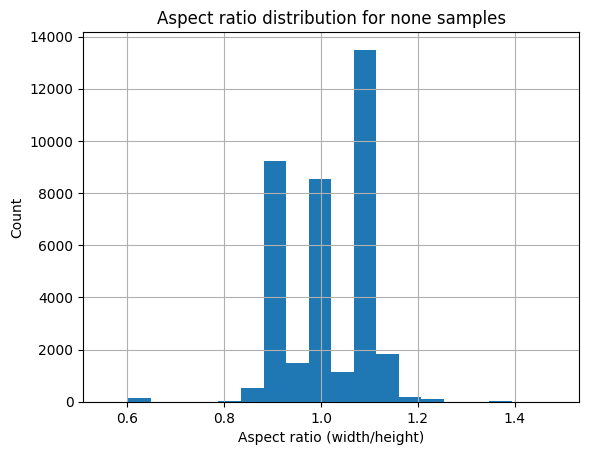

waferMap
0.947368    0.219318
0.981132    0.156921
0.984127    0.146694
1.000000    0.112913
1.057971    0.049897
1.401869    0.047831
0.976744    0.038636
Name: count, dtype: float64


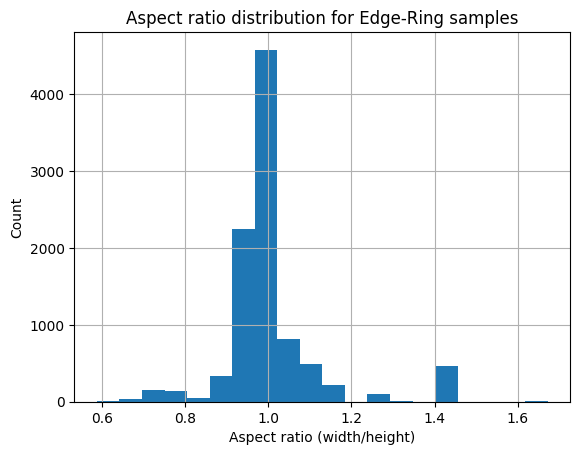

waferMap
1.080000    0.524220
1.000000    0.187005
0.948718    0.040289
1.179487    0.015370
1.282051    0.014672
0.794872    0.014206
1.142857    0.013973
Name: count, dtype: float64


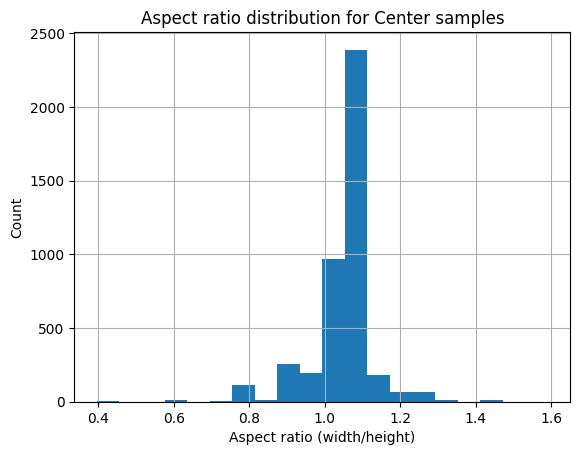

waferMap
1.000000    0.131046
0.948718    0.091154
0.931818    0.075159
1.080000    0.068414
1.133333    0.058971
0.896552    0.044903
0.885714    0.039892
Name: count, dtype: float64


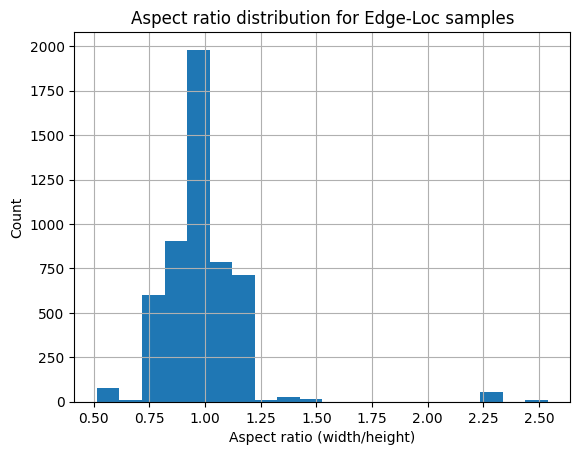

waferMap
1.000000    0.176454
0.885714    0.068466
1.133333    0.067353
0.948718    0.061787
0.794872    0.050654
1.080000    0.047871
0.896552    0.032563
Name: count, dtype: float64


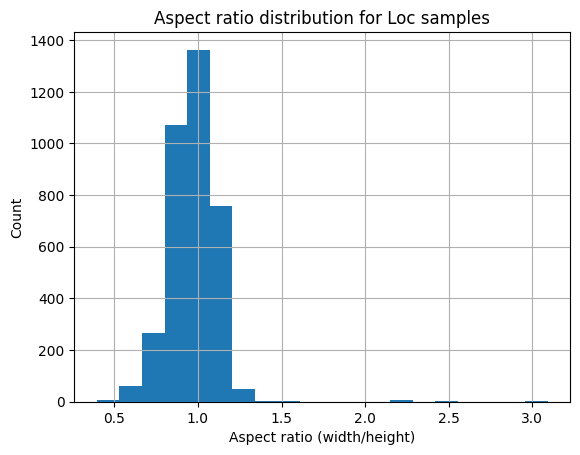

waferMap
1.000000    0.138307
0.896552    0.067058
1.133333    0.057837
0.948718    0.050293
1.134615    0.045264
0.931818    0.040235
0.878788    0.039396
Name: count, dtype: float64


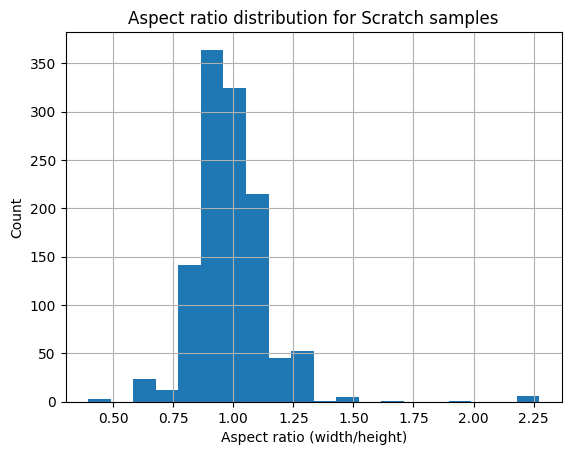

waferMap
1.000000    0.325635
1.243902    0.091224
1.142857    0.078522
1.080000    0.061201
0.948718    0.040416
0.906250    0.036952
1.024390    0.030023
Name: count, dtype: float64


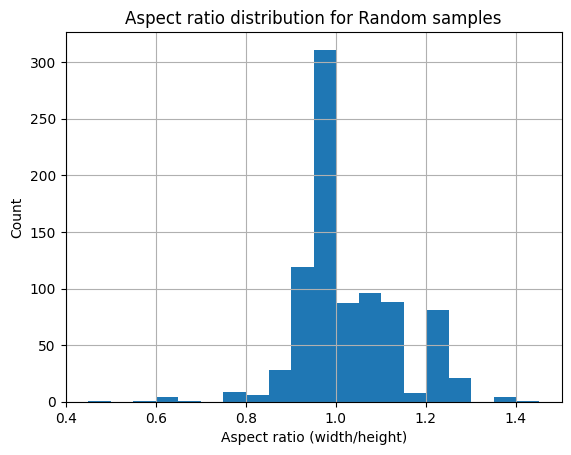

waferMap
1.000000    0.214765
0.878788    0.187919
1.080000    0.140940
0.948718    0.100671
0.925926    0.073826
1.133333    0.033557
0.896552    0.033557
Name: count, dtype: float64


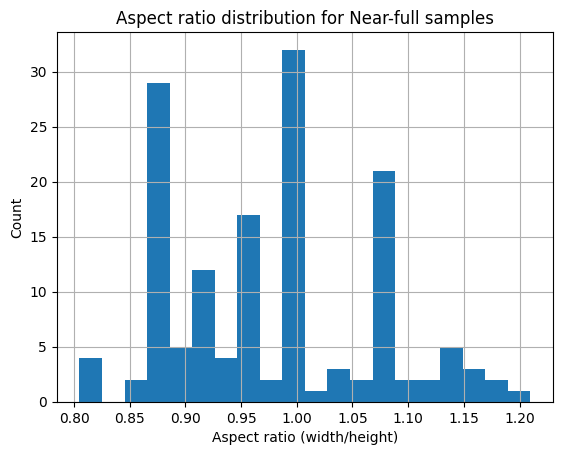

waferMap
1.024390    0.421622
0.885714    0.176577
1.142857    0.059459
1.111111    0.041441
0.948718    0.039640
1.314815    0.030631
1.000000    0.025225
Name: count, dtype: float64


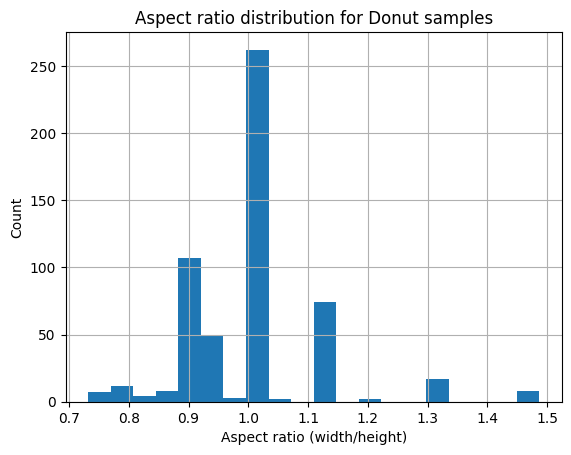

In [60]:
# defect_type = "Edge-Loc"
for defect_type in train.failureType.unique():
    scratch_images = train[train.failureType == defect_type].waferMap 
    scratch_images = pd.concat([scratch_images, test[test.failureType == defect_type].waferMap, validation[validation.failureType == defect_type].waferMap], axis=0)

    aspect_ratio = scratch_images.apply(lambda x: x.shape[1] / x.shape[0] if x.shape[0] > 0 else 0)


    # scratch_images = scratch_images.apply(lambda x: add_noise_to_image(x, noise_level=0.15))

    scratch_images = scratch_images
    angles, linearities, skipped = analyze_scratch_orientations(
            scratch_images,
            defect_value=None,       # None = auto-detect max value as defect
            linearity_threshold=0.0  # set higher (e.g. 0.3) to filter out non-line-like samples
        )

    angles = np.array(angles)
    linearities = np.array(linearities)

    n = 10
    threshold = 0.4
    images = scratch_images[linearities >= threshold]
    angles = np.array(angles)[linearities >= threshold]
    training_samples = images[(angles >= 0) & (angles <= 90)]
    testing_samples = images[(angles > 90) & (angles <= 180)]

    print ((aspect_ratio.value_counts()/len(aspect_ratio)).head(7))
    # aspect_ratio.value_counts().plot(kind='bar', title=f"Aspect ratio distribution for {defect_type} samples", xlabel="Aspect ratio (width/height)", ylabel="Count")
    aspect_ratio.hist(bins=20)
    plt.title(f"Aspect ratio distribution for {defect_type} samples")
    plt.xlabel("Aspect ratio (width/height)")
    plt.ylabel("Count")
    plt.savefig(f"{defect_type.lower()}_aspect_ratio.png", dpi=150)
    plt.show()

# print (f"Displaying {len(images)} {defect_type} samples with linearity >= {threshold}")
# print (f"Training samples (0-90°): {len(training_samples)}")
# print (f"Testing samples (90-180°): {len(testing_samples)}")
# print ("skipped samples (too few defect pixels):", skipped)

# print(f"Analyzed {len(angles)} samples, skipped {skipped} (too few defect pixels)")
# print (min(angles), max(angles))
# print(f"Angle range: {min(angles):.1f} - {max(angles):.1f} deg" if len(angles) > 0 else "No valid angles")
# print(f"Mean linearity: {np.mean(linearities):.3f}" if len(linearities) > 0 else "")

# plot_results(angles, linearities, defect_type=defect_type)

# ranked = rank_by_linearity(images)
# print(f"Ranked {len(ranked)} samples by linearity")
# print("Top 5:", [(i, f"{lin:.3f}, {shape}") for i, a, lin, shape in ranked[:5]])
# print("Bottom 5:", [(i, f"{lin:.3f}, {shape}") for i, a, lin, shape in ranked[-5:]])
# ranked = [[i,a,lin] for i,a,lin,shape in ranked]
# plot_extremes(images, ranked, n=5, defect_type=defect_type)


Generated 15567 fake-data angle samples


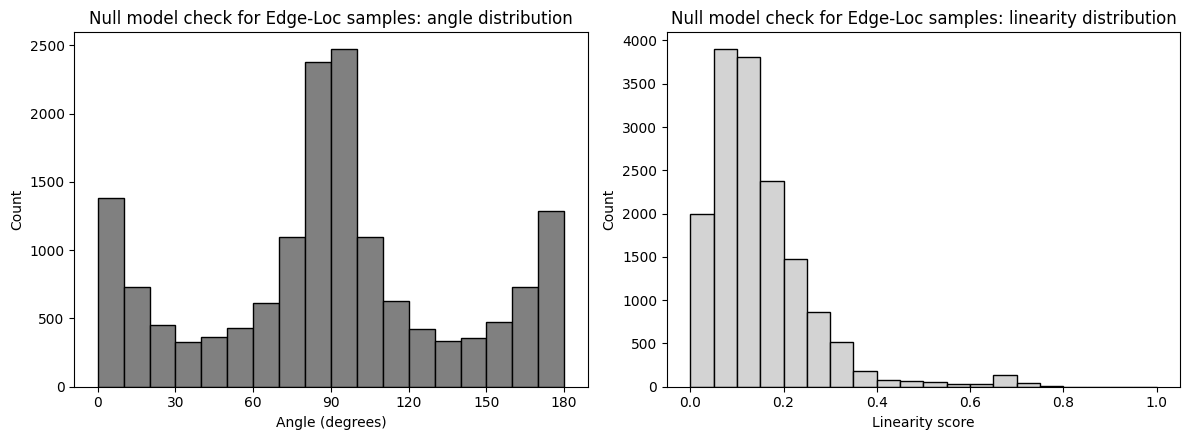

In [69]:
"""
Null-model check: does PCA angle/linearity show fake "orientation"
clustering purely from wafer SHAPE, even when the defect points
themselves are completely random / meaningless?

Logic:
  1. For each real wafer map, figure out which pixels are "inside
     the wafer" (i.e. valid wafer body, not black background/padding).
  2. Scatter N random points uniformly within that valid region —
     these have NO real defect pattern, they're pure noise.
  3. Run the same PCA angle/linearity function on these fake points.
  4. Plot the resulting angle histogram.

If this histogram shows the same bimodal 0/90/180 pattern as your
real defect classes, that's strong evidence wafer SHAPE (not real
defect orientation) is driving the pattern. If it comes out roughly
flat/uniform, the trap is NOT the explanation.
"""

import numpy as np
import matplotlib.pyplot as plt


def get_defect_angle_and_linearity(img: np.ndarray, defect_value=None):
    if defect_value is None:
        defect_value = img.max()
    ys, xs = np.where(img == defect_value)
    if len(xs) < 2:
        return None, None
    coords = np.stack([xs, ys], axis=1).astype(np.float64)
    coords -= coords.mean(axis=0)
    cov = np.cov(coords, rowvar=False)
    eigvals, eigvecs = np.linalg.eigh(cov)
    major_idx = np.argmax(eigvals)
    minor_idx = 1 - major_idx
    major_vec = eigvecs[:, major_idx]
    angle_rad = np.arctan2(major_vec[1], major_vec[0])
    angle_deg = np.degrees(angle_rad) % 180
    lam_major = eigvals[major_idx]
    lam_minor = eigvals[minor_idx]
    linearity = 0.0 if (lam_major + lam_minor) == 0 else float((lam_major - lam_minor) / (lam_major + lam_minor))
    return angle_deg, linearity


def get_valid_wafer_mask(img: np.ndarray, background_value=0):
    """
    Returns a boolean mask of pixels that are considered "inside the
    wafer" (i.e. NOT background/padding). Assumes background/no-die
    pixels are `background_value` (commonly 0). Adjust if your maps
    encode background differently (e.g. if 0 = no die is itself a
    valid category distinct from black padding around an oval wafer).
    """
    return img != background_value


def scatter_fake_points(valid_mask: np.ndarray, n_points: int):
    """
    Scatters n_points random points uniformly among the True
    locations of valid_mask (i.e. within the real wafer body shape,
    ignoring background/padding pixels).

    Returns a 2D array same shape as valid_mask, with n_points
    positions set to 1, rest 0 — mimicking a "fake defect" image
    with no real pattern.
    """
    ys, xs = np.where(valid_mask)
    if len(xs) < n_points:
        n_points = len(xs)
    if n_points < 2:
        return None

    chosen = np.random.choice(len(xs), size=n_points, replace=False)
    fake_img = np.zeros_like(valid_mask, dtype=np.uint8)
    fake_img[ys[chosen], xs[chosen]] = 1
    return fake_img


def null_model_check(images, n_points_per_sample=None, background_value=0, trials_per_image=1):
    """
    images: list of 2D numpy arrays (real wafer maps — used ONLY for
            their shape/valid-region, not their real defect pattern).
    n_points_per_sample: how many fake points to scatter per wafer.
            If None, uses the number of real defect pixels in that
            wafer (so fake data has a similar "density" to real data).
    trials_per_image: run multiple random draws per wafer for a
            smoother / more reliable histogram.

    Returns: angles, linearities (lists, same format as your real
             analysis, but computed on FAKE random data).
    """
    angles = []
    linearities = []

    for img in images:
        valid_mask = get_valid_wafer_mask(img, background_value=background_value)

        if n_points_per_sample is None:
            # Match the real defect pixel count for this image, so
            # fake data has similar sparsity to the real thing.
            defect_val = img.max()
            n_pts = int((img == defect_val).sum())
        else:
            n_pts = n_points_per_sample

        if n_pts < 2:
            continue

        for _ in range(trials_per_image):
            fake_img = scatter_fake_points(valid_mask, n_pts)
            if fake_img is None:
                continue
            angle_deg, linearity = get_defect_angle_and_linearity(fake_img, defect_value=1)
            if angle_deg is not None:
                angles.append(angle_deg)
                linearities.append(linearity)

    return angles, linearities


def plot_null_model_result(angles, linearities, title_prefix="Null model (random points)"):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    axes[0].hist(angles, bins=18, range=(0, 180), color="gray", edgecolor="black")
    axes[0].set_title(f"{title_prefix}: angle distribution")
    axes[0].set_xlabel("Angle (degrees)")
    axes[0].set_ylabel("Count")
    axes[0].set_xticks(range(0, 181, 30))

    axes[1].hist(linearities, bins=20, range=(0, 1), color="lightgray", edgecolor="black")
    axes[1].set_title(f"{title_prefix}: linearity distribution")
    axes[1].set_xlabel("Linearity score")
    axes[1].set_ylabel("Count")

    plt.tight_layout()
    plt.savefig(f"{title_prefix.replace(' ', '_').lower()}.png", dpi=150)
    plt.show()



defect_type = "Edge-Loc"  # or "Edge-Ring", "Center", etc. — pick one to analyze
wafer_images = pd.concat([
    train[train.failureType == defect_type].waferMap,
    test[test.failureType == defect_type].waferMap,
    validation[validation.failureType == defect_type].waferMap
], axis=0)
wafer_images = [np.array(im) for im in wafer_images]



if not wafer_images:
    print("No images loaded — update the data-loading section above.")
else:
    angles, linearities = null_model_check(
        wafer_images,
        n_points_per_sample=None,   # None = match real defect pixel count per wafer
        background_value=0,          # adjust if your background isn't 0
        trials_per_image=3           # run a few random draws per wafer for stability
    )
    print(f"Generated {len(angles)} fake-data angle samples")
    plot_null_model_result(angles, linearities, title_prefix=f"Null model check for {defect_type} samples")

Real (filtered, linearity>=0.35) samples: 130
Null model samples: 3579


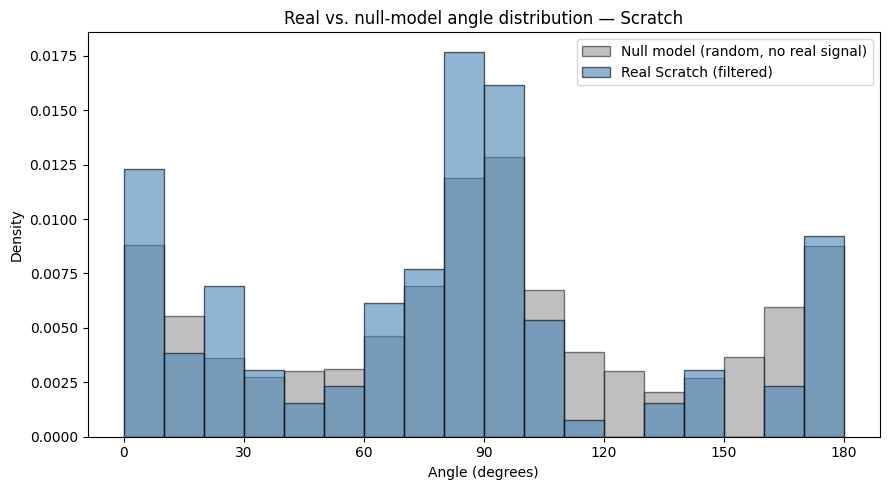


Chi-square test (real vs. null-model shape):
  chi2 = 28.59, p-value = 0.0385
  --> Real distribution is significantly different from the null-model baseline.
      This suggests there IS a genuine orientation signal beyond the wafer-shape artifact.


In [70]:
"""
Compares the REAL (linearity-filtered) Scratch angle distribution
against the NULL MODEL baseline (random points scattered in the same
real wafer shapes) to check whether Scratch shows a genuine excess
of orientation clustering beyond what wafer shape alone produces.

Both histograms are density-normalized (not raw counts) so they can
be compared directly even though the null model uses far more samples
per wafer (multiple random trials) than the real filtered data.

Also runs a chi-square goodness-of-fit test: treats the null model's
angle distribution as the "expected" (no real signal) distribution,
and checks whether the real data's distribution deviates from it more
than chance would predict.
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chisquare


def get_defect_angle_and_linearity(img: np.ndarray, defect_value=None):
    if defect_value is None:
        defect_value = img.max()
    ys, xs = np.where(img == defect_value)
    if len(xs) < 2:
        return None, None
    coords = np.stack([xs, ys], axis=1).astype(np.float64)
    coords -= coords.mean(axis=0)
    cov = np.cov(coords, rowvar=False)
    eigvals, eigvecs = np.linalg.eigh(cov)
    major_idx = np.argmax(eigvals)
    minor_idx = 1 - major_idx
    major_vec = eigvecs[:, major_idx]
    angle_rad = np.arctan2(major_vec[1], major_vec[0])
    angle_deg = np.degrees(angle_rad) % 180
    lam_major = eigvals[major_idx]
    lam_minor = eigvals[minor_idx]
    linearity = 0.0 if (lam_major + lam_minor) == 0 else float((lam_major - lam_minor) / (lam_major + lam_minor))
    return angle_deg, linearity


def get_valid_wafer_mask(img: np.ndarray, background_value=0):
    return img != background_value


def scatter_fake_points(valid_mask: np.ndarray, n_points: int):
    ys, xs = np.where(valid_mask)
    if len(xs) < n_points:
        n_points = len(xs)
    if n_points < 2:
        return None
    chosen = np.random.choice(len(xs), size=n_points, replace=False)
    fake_img = np.zeros_like(valid_mask, dtype=np.uint8)
    fake_img[ys[chosen], xs[chosen]] = 1
    return fake_img


def get_real_angles(images, linearity_threshold, defect_value=None):
    """
    images: list/Series of 2D numpy arrays (real wafer maps for one class).
    Returns angles for samples passing the linearity threshold.
    """
    angles = []
    for img in images:
        angle_deg, linearity = get_defect_angle_and_linearity(img, defect_value)
        if angle_deg is not None and linearity >= linearity_threshold:
            angles.append(angle_deg)
    return angles


def get_null_angles(images, background_value=0, trials_per_image=3):
    """
    images: same list/Series of real wafer maps (shape used only,
    not real defect content). Number of fake points per wafer matches
    that wafer's real defect pixel count.
    Returns angles from purely random scatter — the "no real signal"
    baseline.
    """
    angles = []
    for img in images:
        valid_mask = get_valid_wafer_mask(img, background_value=background_value)
        defect_val = img.max()
        n_pts = int((img == defect_val).sum())
        if n_pts < 2:
            continue
        for _ in range(trials_per_image):
            fake_img = scatter_fake_points(valid_mask, n_pts)
            if fake_img is None:
                continue
            angle_deg, _ = get_defect_angle_and_linearity(fake_img, defect_value=1)
            if angle_deg is not None:
                angles.append(angle_deg)
    return angles


def compare_real_vs_null(images, linearity_threshold=0.35, background_value=0,
                          trials_per_image=3, bins=18, class_name="Scratch"):
    """
    Runs both real (filtered) and null-model angle extraction on the
    same set of images, plots them overlaid (density-normalized), and
    runs a chi-square test comparing the shapes of the two distributions.
    """
    real_angles = get_real_angles(images, linearity_threshold)
    null_angles = get_null_angles(images, background_value, trials_per_image)

    print(f"Real (filtered, linearity>={linearity_threshold}) samples: {len(real_angles)}")
    print(f"Null model samples: {len(null_angles)}")

    # --- Plot overlay (density-normalized so shapes are comparable) ---
    plt.figure(figsize=(9, 5))
    bin_edges = np.linspace(0, 180, bins + 1)
    plt.hist(null_angles, bins=bin_edges, density=True, alpha=0.5,
              color="gray", edgecolor="black", label="Null model (random, no real signal)")
    plt.hist(real_angles, bins=bin_edges, density=True, alpha=0.6,
              color="steelblue", edgecolor="black", label=f"Real {class_name} (filtered)")
    plt.xlabel("Angle (degrees)")
    plt.ylabel("Density")
    plt.title(f"Real vs. null-model angle distribution — {class_name}")
    plt.xticks(range(0, 181, 30))
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"real_vs_null_{class_name.lower()}.png", dpi=150)
    plt.show()

    # --- Chi-square test: does real deviate from null more than chance? ---
    real_counts, _ = np.histogram(real_angles, bins=bin_edges)
    null_counts, _ = np.histogram(null_angles, bins=bin_edges)

    # Scale null counts to match real sample size (chisquare needs
    # comparable totals between observed and expected)
    null_counts_scaled = null_counts * (real_counts.sum() / null_counts.sum())

    # Avoid zero-expected-count bins (chisquare requires nonzero expected)
    null_counts_scaled = np.clip(null_counts_scaled, 1e-6, None)

    chi2_stat, p_value = chisquare(f_obs=real_counts, f_exp=null_counts_scaled)
    print(f"\nChi-square test (real vs. null-model shape):")
    print(f"  chi2 = {chi2_stat:.2f}, p-value = {p_value:.4f}")
    if p_value < 0.05:
        print("  --> Real distribution is significantly different from the null-model baseline.")
        print("      This suggests there IS a genuine orientation signal beyond the wafer-shape artifact.")
    else:
        print("  --> Real distribution is NOT significantly different from the null-model baseline.")
        print("      The bimodal pattern may be fully explained by wafer shape, not real defect orientation.")

    return real_angles, null_angles, chi2_stat, p_value



# -------------------------------------------------------------
# Load your Scratch images the same way as before, e.g.:

scratch_images = pd.concat([
    train[train.failureType == "Scratch"].waferMap,
    test[test.failureType == "Scratch"].waferMap,
    validation[validation.failureType == "Scratch"].waferMap
], axis=0)


if not len(scratch_images):
    print("No images loaded — update the data-loading section above.")
else:
    compare_real_vs_null(
        scratch_images,
        linearity_threshold=0.35,
        background_value=0,
        trials_per_image=3,
        class_name="Scratch"
    )